# Titanic — Advanced Modeling
**Goal:** Beat the baseline accuracy (~82%) using Advanced Feature Engineering and Hyperparameter Tuning.

### Features we are adding:
1. **Deck:** Extracted from `Cabin` (Letter represents the ship deck).
2. **Age_Class:** `Age * Pclass` (captures the interaction between age and wealth).
3. **Fare_Bin:** Grouping Fare into 4 categories (Low to Luxury).
4. **Is_Mother:** Binary flag for females with children.
5. **Title:** Mr, Mrs, Miss, Master, Other.

## 1. Load Data & Initial Prep

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Advanced Feature Engineering

In [2]:
# Extract Title
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Other')
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
print('Titles after grouping:\n', df['Title'].value_counts())

Titles after grouping:
 Title
Mr        517
Miss      185
Mrs       126
Master     40
Other      23
Name: count, dtype: int64


<>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\kkp18\AppData\Local\Temp\ipykernel_17160\3419521375.py:2: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)


In [3]:
# Extract Deck from Cabin
df['Deck'] = df['Cabin'].str[0].fillna('U') # U for Unknown
print('Decks:\n', df['Deck'].value_counts())

Decks:
 Deck
U    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64


In [4]:
# Is Mother feature
df['Is_Mother'] = 0
df.loc[(df['Sex'] == 'female') & (df['Parch'] > 0), 'Is_Mother'] = 1
print('Is_Mother count:', df['Is_Mother'].sum())

Is_Mother count: 120


In [5]:
# Family Size & IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

## 3. Data Cleaning

In [6]:
# Fill missing Age with median per Pclass and Title
df['Age'] = df.groupby(['Pclass', 'Title'])['Age'].transform(lambda x: x.fillna(x.median()))

# Fill Embarked with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Age * Class interaction
df['Age_Class'] = df['Age'] * df['Pclass']

# Fare Bins
df['Fare_Bin'] = pd.qcut(df['Fare'], 4, labels=False)

# Drop columns that were used to create features
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
print('Remaining missing values:', df.isnull().sum().sum())

Remaining missing values: 0


## 4. Encoding

In [7]:
# Encode Sex
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# One-Hot Encode Title, Deck, and Embarked
df = pd.get_dummies(df, columns=['Title', 'Deck', 'Embarked'], drop_first=True)

# Convert bool columns to int
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

print('Final Shape:', df.shape)
df.head()

Final Shape: (891, 26)


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Is_Mother,FamilySize,IsAlone,...,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Deck_U,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,0,2,0,...,0,0,0,0,0,0,0,1,0,1
1,1,1,1,38.0,1,0,71.2833,0,2,0,...,0,1,0,0,0,0,0,0,0,0
2,1,3,1,26.0,0,0,7.9250,0,1,1,...,0,0,0,0,0,0,0,1,0,1
3,1,1,1,35.0,1,0,53.1000,0,2,0,...,0,1,0,0,0,0,0,0,0,1
4,0,3,0,35.0,0,0,8.0500,0,1,1,...,0,0,0,0,0,0,0,1,0,1


## 5. Prep for Modeling

In [8]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features (Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 6. Tuning Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=1000)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

grid_lr = GridSearchCV(lr, param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train_scaled, y_train)

print('Best LR Parameters:', grid_lr.best_params_)
best_lr = grid_lr.best_estimator_
print('LR Test Accuracy:', accuracy_score(y_test, best_lr.predict(X_test_scaled)))

c:\Users\kkp18\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kkp18\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\kkp18\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty=

Best LR Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
LR Test Accuracy: 0.8212290502793296


c:\Users\kkp18\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\kkp18\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kkp18\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 7. Tuning Random Forest

In [10]:
# Define the grid
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 8, 10],
    'min_samples_split': [2, 5, 10]
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv=5, n_jobs=-1, verbose=1)
grid_rf.fit(X_train_scaled, y_train)

print('Best RF Parameters:', grid_rf.best_params_)
best_rf = grid_rf.best_estimator_
print('RF Test Accuracy:', accuracy_score(y_test, best_rf.predict(X_test_scaled)))

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best RF Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 200}
RF Test Accuracy: 0.8491620111731844


## 8. Final Comparison

In [11]:
results = pd.DataFrame({
    'Model': ['Tuned LR', 'Tuned RF'],
    'Accuracy': [accuracy_score(y_test, best_lr.predict(X_test_scaled)), 
                 accuracy_score(y_test, best_rf.predict(X_test_scaled))]
})
print(results.sort_values(by='Accuracy', ascending=False))

print('\nBest Model classification report:\n', 
      classification_report(y_test, best_rf.predict(X_test_scaled)))

      Model  Accuracy
1  Tuned RF  0.849162
0  Tuned LR  0.821229

Best Model classification report:
               precision    recall  f1-score   support

           0       0.85      0.90      0.87       105
           1       0.84      0.78      0.81        74

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



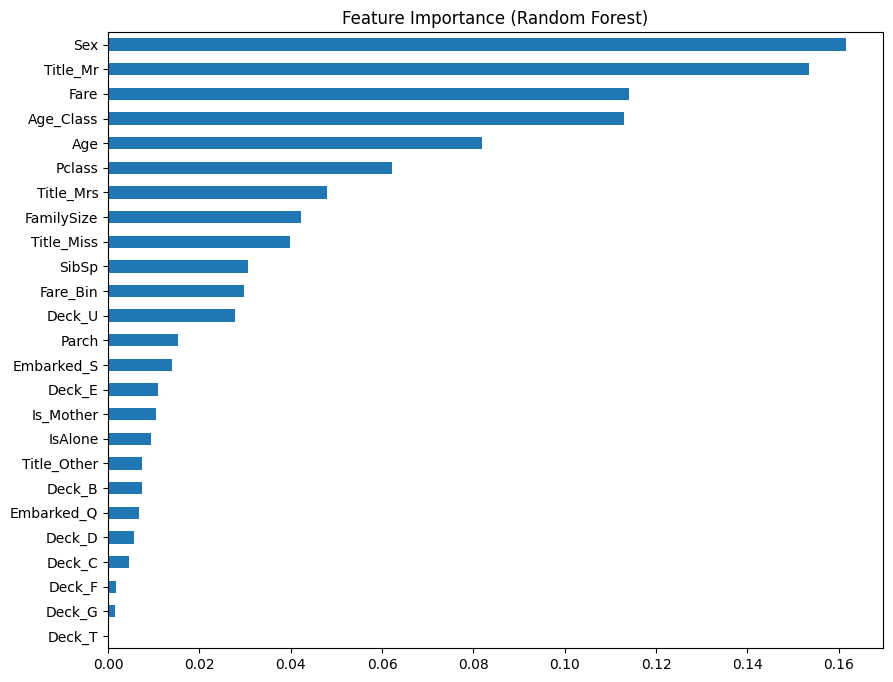

In [12]:
# Plot RF Feature Importance
importances = pd.Series(best_rf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 8))
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance (Random Forest)')
plt.show()